# Assignment 2 — Multilayer Perceptron (MLP) for Iris Classification

**Aim:** Design and implement a Multilayer Perceptron (MLP) for classification of the Iris dataset, and evaluate its performance using accuracy and a confusion matrix.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

## 2. Load the Iris Dataset

The Iris dataset has 150 samples with 4 features and 3 classes (Setosa, Versicolor, Virginica).

In [2]:
# Load the Iris dataset
iris = load_iris()

X = iris.data        # Features (150, 4)
y = iris.target      # Labels (0, 1, 2)

# Display dataset info
print("Feature names:", iris.feature_names)
print("Target names: ", iris.target_names)
print("Dataset shape:", X.shape)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names:  ['setosa' 'versicolor' 'virginica']
Dataset shape: (150, 4)


## 3. Data Preprocessing

In [3]:
# Normalize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# One-hot encode the target labels for multi-class classification
y_encoded = to_categorical(y, num_classes=3)

print("Scaled features shape:", X_scaled.shape)
print("Encoded labels shape: ", y_encoded.shape)
print("\nExample encoded label:", y_encoded[0])

Scaled features shape: (150, 4)
Encoded labels shape:  (150, 3)

Example encoded label: [1. 0. 0.]


## 4. Train-Test Split

In [4]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set: ", X_test.shape)

Training set: (120, 4)
Testing set:  (30, 4)


## 5. Build the MLP Model

We build a Multilayer Perceptron with:
- Input layer: 4 features
- Hidden layer 1: 16 neurons, ReLU activation
- Hidden layer 2: 8 neurons, ReLU activation
- Output layer: 3 neurons, Softmax activation (one per class)

In [5]:
# Build the MLP model
model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),   # Hidden layer 1
    Dense(8, activation='relu'),                       # Hidden layer 2
    Dense(3, activation='softmax')                     # Output layer (3 classes)
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\Swaraj Shedge\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model

In [6]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.6458 - loss: 1.0200 - val_accuracy: 0.5000 - val_loss: 1.0609
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6979 - loss: 0.9805 - val_accuracy: 0.5417 - val_loss: 1.0145
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7083 - loss: 0.9432 - val_accuracy: 0.7500 - val_loss: 0.9690
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7708 - loss: 0.9073 - val_accuracy: 0.9167 - val_loss: 0.9265
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8229 - loss: 0.8699 - val_accuracy: 0.9583 - val_loss: 0.8865
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8333 - loss: 0.8337 - val_accuracy: 0.9583 - val_loss: 0.8481
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8333 - loss: 0.8021 - val_accuracy: 0.9583 - val_loss: 0.8097
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8542 - loss: 0.7694 - val_accuracy: 0.9167 - val_loss: 0.7722


## 7. Evaluate the Model

In [7]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss    : {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Loss    : 0.1795
Test Accuracy: 100.00%


## 8. Confusion Matrix

The confusion matrix shows how many samples were correctly and incorrectly classified for each class.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


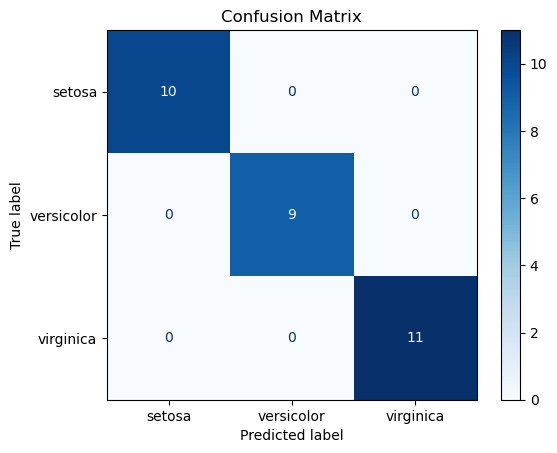


Accuracy (sklearn): 100.00%


In [8]:
# Get predictions on the test set
y_pred = model.predict(X_test)

# Convert one-hot encoded predictions and labels back to class indices
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Calculate confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Display the confusion matrix as a heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Print accuracy using sklearn
acc = accuracy_score(y_true_classes, y_pred_classes)
print(f"\nAccuracy (sklearn): {acc * 100:.2f}%")

## 9. Training Curves

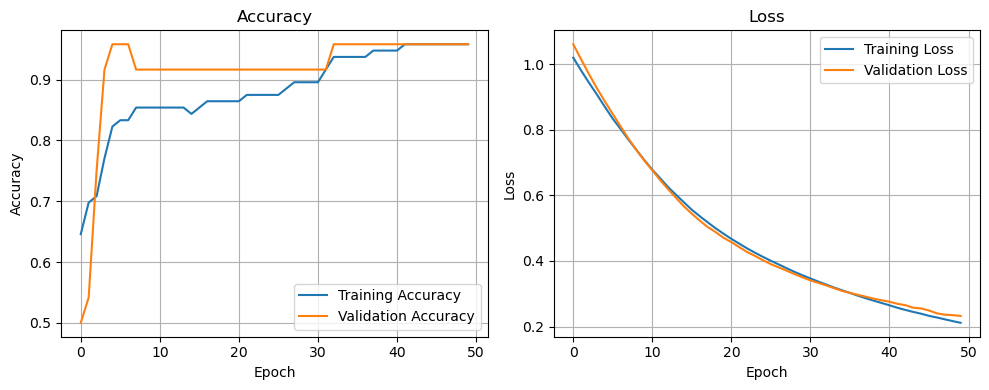

In [9]:
# Plot training and validation accuracy
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Conclusion

In this assignment, we:
1. Loaded and preprocessed the Iris dataset.
2. Built a Multilayer Perceptron (MLP) with two hidden layers using Keras.
3. Trained the model for 50 epochs.
4. Evaluated the model using test accuracy.
5. Displayed the confusion matrix to analyze per-class classification performance.

The MLP achieves high accuracy on the Iris dataset, which is a well-separated, simple classification problem. The confusion matrix confirms that the model correctly classifies most samples across all three classes.